# Deep Learning - 2026
## Trabalho Final - Classificação de Defeitos em Peças Fundidas


**Tema:** Classificação binária de imagens para deteção de defeitos

### Enquadramento do problema
Este trabalho pretende construir um modelo de Deep Learning capaz de classificar imagens de peças fundidas em duas classes: **def_front** e **ok_front**. Em termos práticos, o objetivo é distinguir imagens com defeito visível de imagens sem defeito, explorando uma abordagem supervisionada baseada em redes neuronais convolucionais.

### Estratégia seguida
A estrutura do notebook foi organizada em três etapas complementares:
1. **Baseline model** — criar uma primeira referência simples, adequada ao problema e suficientemente estável para servir de ponto de comparação;
2. **Overfit model** — aumentar a capacidade do modelo para observar até que ponto uma arquitetura mais forte pode começar a perder generalização;
3. **Regularized model** — aplicar mecanismos de regularização para reduzir esse risco e obter uma solução final mais robusta.

### Critério de avaliação
A análise de cada modelo é feita com base em:
- evolução de **accuracy** e **loss** por epoch;
- comparação entre **treino** e **validação** para perceber a capacidade de generalização;
- desempenho final no conjunto de **teste**, através de accuracy, precision, recall e F1-score.

A ideia central não é apenas obter um modelo com boa performance, mas também perceber **como** e **porquê** esse desempenho acontece ao longo do treino.


# Dependencies

In [ ]:
import seaborn as sns


# %pip install tensorflow scikit-learn matplotlib pandas

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

from IPython.display import display, Markdown


# Auxiliary functions / code

In [2]:
def plot_accuracy_loss(history, title='Model history'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Loss')

    plt.show()


def summarize_history(history, model_name):
    val_acc = history.history['val_accuracy']
    val_loss = history.history['val_loss']

    return pd.DataFrame([{
        'model': model_name,
        'epochs_ran': len(history.history['accuracy']),
        'best_train_accuracy': max(history.history['accuracy']),
        'final_train_accuracy': history.history['accuracy'][-1],
        'best_val_accuracy': max(val_acc),
        'final_val_accuracy': val_acc[-1],
        'best_val_loss': min(val_loss),
        'final_val_loss': val_loss[-1]
    }]).round(4)


def build_model_results_table(model_name, summary_df, test_results):
    row = summary_df.iloc[0]
    return pd.DataFrame([{
        'model': model_name,
        'epochs_ran': int(row['epochs_ran']),
        'best_val_accuracy': row['best_val_accuracy'],
        'final_val_accuracy': row['final_val_accuracy'],
        'best_val_loss': row['best_val_loss'],
        'final_val_loss': row['final_val_loss'],
        'test_accuracy': round(test_results['accuracy'], 4),
        'test_precision_defect': round(test_results['precision'], 4),
        'test_recall_defect': round(test_results['recall'], 4),
        'test_f1_defect': round(test_results['f1'], 4)
    }])


def count_images_in_folder(folder_path):
    image_extensions = {'.png', '.jpg', '.jpeg', '.bmp'}
    return sum(1 for p in Path(folder_path).rglob('*') if p.suffix.lower() in image_extensions)


def get_class_distribution(folder_path):
    folder = Path(folder_path)
    rows = []
    for class_dir in sorted([p for p in folder.iterdir() if p.is_dir()]):
        n_images = count_images_in_folder(class_dir)
        rows.append({'class_name': class_dir.name, 'n_images': n_images})
    df = pd.DataFrame(rows)
    df['pct'] = (df['n_images'] / df['n_images'].sum() * 100).round(2)
    return df


def normalize_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def make_balanced_subset(dataset, per_class_limit, batch_size, seed=42, shuffle=True):
    if per_class_limit is None:
        return dataset

    images = []
    labels = []
    class_counts = {0: 0, 1: 0}

    for image, label in dataset.unbatch().as_numpy_iterator():
        class_id = int(np.squeeze(label))
        if class_counts[class_id] < per_class_limit:
            images.append(image)
            labels.append([float(class_id)])
            class_counts[class_id] += 1

        if all(v >= per_class_limit for v in class_counts.values()):
            break

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.float32)

    if shuffle:
        rng = np.random.default_rng(seed)
        indices = np.arange(len(images))
        rng.shuffle(indices)
        images = images[indices]
        labels = labels[indices]

    subset_ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if shuffle:
        subset_ds = subset_ds.shuffle(buffer_size=len(images), seed=seed, reshuffle_each_iteration=True)
    return subset_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def count_examples(dataset):
    total = 0
    for batch_images, _ in dataset:
        total += batch_images.shape[0]
    return int(total)


def evaluate_model(model, dataset, class_names, model_name='Model', dataset_name='Test',
                   show_confusion_matrix=False, print_classification_report=False, verbose=True):
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0).reshape(-1)
        preds = (probs >= 0.5).astype(int)
        y_prob.extend(probs.tolist())
        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().reshape(-1).astype(int).tolist())

    accuracy = accuracy_score(y_true, y_pred)
    # As métricas precision/recall/F1 são calculadas para a classe de defeito (label 0),
    # por ser a classe mais relevante neste problema de controlo de qualidade.
    precision = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    if verbose:
        print(f'{model_name} - {dataset_name} accuracy: {accuracy:.4f}')
        print(f'{model_name} - {dataset_name} precision (def_front): {precision:.4f}')
        print(f'{model_name} - {dataset_name} recall (def_front): {recall:.4f}')
        print(f'{model_name} - {dataset_name} F1-score (def_front): {f1:.4f}')

    if print_classification_report:
        print()
        print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    if show_confusion_matrix:
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f'{model_name} - Confusion Matrix')
        plt.xlabel('Predicted label')
        plt.ylabel('True label')
        plt.show()

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob
    }


def show_prediction_example(model, dataset, class_names, n_examples=1, seed=42):
    rng = np.random.default_rng(seed)

    images_all = []
    labels_all = []

    for images, labels in dataset.unbatch().batch(128):
        images_all.append(images.numpy())
        labels_all.append(labels.numpy())

    images_all = np.concatenate(images_all, axis=0)
    labels_all = np.concatenate(labels_all, axis=0).reshape(-1).astype(int)

    idxs = rng.choice(len(images_all), size=n_examples, replace=False)

    for idx in idxs:
        image = images_all[idx]
        true_label = labels_all[idx]
        prob = float(model.predict(image[np.newaxis, ...], verbose=0)[0][0])
        pred_label = int(prob >= 0.5)

        plt.figure(figsize=(4, 4))
        plt.imshow(image.squeeze(), cmap='gray')
        plt.axis('off')
        plt.title(
            f'Real: {class_names[true_label]}\n'
            f'Predição: {class_names[pred_label]}\n'
            f'Probabilidade de ok_front: {prob:.4f}\n'
            f'Probabilidade de def_front: {1 - prob:.4f}'
        )
        plt.show()


def build_validation_comparison_table(summary_df, validation_results):
    row = summary_df.iloc[0]
    return pd.DataFrame([{
        'model': row['model'],
        'epochs_ran': int(row['epochs_ran']),
        'best_train_accuracy': row['best_train_accuracy'],
        'final_train_accuracy': row['final_train_accuracy'],
        'best_val_accuracy': row['best_val_accuracy'],
        'final_val_accuracy': row['final_val_accuracy'],
        'best_val_loss': row['best_val_loss'],
        'final_val_loss': row['final_val_loss'],
        'val_precision_defect': validation_results['precision'],
        'val_recall_defect': validation_results['recall'],
        'val_f1_defect': validation_results['f1']
    }]).round(4)


# Load Data

In [ ]:
# ALTERAR APENAS ESTA PATH SE NECESSÁRIO
# Estrutura usada neste projeto:
# archive/casting_data/casting_data/train
# archive/casting_data/casting_data/test
# DATASET_ROOT = Path('/User//archive/casting_data/casting_data')

DATASET_ROOT = Path('archive/casting_data/casting_data')

train_dir = DATASET_ROOT / 'train'
test_dir = DATASET_ROOT / 'test'

assert train_dir.exists(), f'Pasta não encontrada: {train_dir}'
assert test_dir.exists(), f'Pasta não encontrada: {test_dir}'


## Data information

In [4]:
train_distribution = get_class_distribution(train_dir)
test_distribution = get_class_distribution(test_dir)

display(train_distribution)
display(test_distribution)


,class_name,n_images,pct
0,def_front,3758,56.66
1,ok_front,2875,43.34


,class_name,n_images,pct
0,def_front,453,63.36
1,ok_front,262,36.64


## Explore the data

In [5]:
IMG_HEIGHT = 96
IMG_WIDTH = 96
BATCH_SIZE = 64
SEED = 42
VAL_SPLIT = 0.2


In [6]:

class_names = ['def_front', 'ok_front']

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset='training',
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='binary'
)

print('Classes:', class_names)
print('Train batches:', tf.data.experimental.cardinality(train_ds).numpy())
print('Validation batches:', tf.data.experimental.cardinality(val_ds).numpy())
print('Test batches:', tf.data.experimental.cardinality(test_ds).numpy())


Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Found 6633 files belonging to 2 classes.
Using 1326 files for validation.
Found 715 files belonging to 2 classes.
Classes: ['def_front', 'ok_front']
Train batches: 83
Validation batches: 21
Test batches: 12


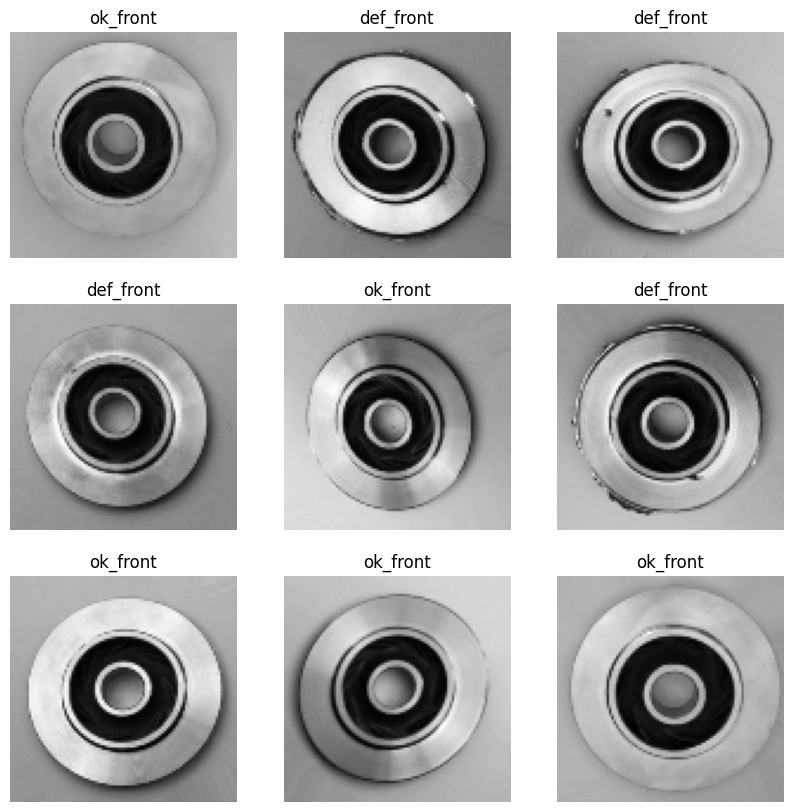

In [7]:

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(tf.squeeze(images[i]), cmap='gray')
        label_index = int(labels[i].numpy()[0])
        plt.title(class_names[label_index])
        plt.axis('off')
plt.show()

As imagens do dataset são em **grayscale** e, nesta versão do trabalho, são redimensionadas para **96x96**. Esta escolha permite reduzir o custo computacional sem descaracterizar o problema, já que o padrão visual associado ao defeito continua visível nesta resolução. O objetivo é equilibrar eficiência de treino com qualidade suficiente de informação visual para a classificação.

# Transform Data

## Normalize data

In [8]:
train_ds = train_ds.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(normalize_image, num_parallel_calls=tf.data.AUTOTUNE)

## Improve input pipeline

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

USE_TRAIN_SUBSAMPLE = True
TRAIN_LIMIT_PER_CLASS = 1500
OVERFIT_TRAIN_LIMIT_PER_CLASS = 1000

train_ds_full = train_ds
val_ds_full = val_ds
test_ds_full = test_ds

if USE_TRAIN_SUBSAMPLE:
    train_ds = make_balanced_subset(
        train_ds_full,
        per_class_limit=TRAIN_LIMIT_PER_CLASS,
        batch_size=BATCH_SIZE,
        seed=SEED,
        shuffle=True
    )

    overfit_train_ds = make_balanced_subset(
        train_ds_full,
        per_class_limit=OVERFIT_TRAIN_LIMIT_PER_CLASS,
        batch_size=BATCH_SIZE,
        seed=SEED,
        shuffle=True
    )
else:
    train_ds = train_ds_full
    overfit_train_ds = train_ds_full

val_ds = val_ds_full.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds_full.cache().prefetch(buffer_size=AUTOTUNE)

subset_summary_df = pd.DataFrame([
    {'partition': 'train_baseline_regularized', 'examples': count_examples(train_ds)},
    {'partition': 'train_overfit', 'examples': count_examples(overfit_train_ds)},
    {'partition': 'validation', 'examples': count_examples(val_ds)},
    {'partition': 'test', 'examples': count_examples(test_ds)}
])
subset_summary_df


,partition,examples
0,train_baseline_regularized,3000
1,train_overfit,2000
2,validation,1326
3,test,715


### Nota metodológica

Neste notebook, a separação entre **treino**, **validação** e **teste** é preservada do início ao fim.  
A única redução de dados aplicada foi feita **apenas na partição de treino**, com o objetivo de reduzir o custo computacional e tornar a experimentação mais eficiente, sem comprometer a avaliação final do modelo.

Assim, a lógica seguida é a seguinte:

- **train**: usado para aprendizagem dos modelos;
- **validation**: usado para acompanhar o comportamento ao longo das epochs e apoiar a comparação entre modelos;
- **test**: reservado para avaliação final da generalização.

Desta forma, a análise final continua a ser feita em dados não usados no processo de treino.

Nesta configuração, o **baseline** e o **modelo regularizado** usam um subconjunto de treino moderado e representativo, enquanto o **modelo intermédio** usa um subconjunto de treino ligeiramente menor para facilitar a observação de overfitting.  
A validação e o teste permanecem separados e inalterados.

Esta escolha foi intencional: ao reduzir apenas os dados de treino do modelo intermédio e ao aumentar a capacidade da rede, tenta-se criar um contexto mais favorável ao sobreajuste sem contaminar a avaliação final. Mesmo assim, como se verá adiante, o overfitting observado foi **moderado** e não extremo, o que também é um resultado interpretável neste problema.


# Definição do problema

## Objetivo
Construir um classificador binário capaz de identificar automaticamente se uma imagem pertence à classe **def_front** ou **ok_front**.

## Porque usar CNN
Como se trata de um problema de imagem, faz sentido recorrer a **Convolutional Neural Networks (CNNs)**. Este tipo de arquitetura é adequado para captar padrões espaciais locais, como bordas, contornos, textura e pequenas irregularidades visuais, que são precisamente o tipo de informação relevante para distinguir uma peça com defeito de uma peça sem defeito.

## Lógica experimental
Em vez de testar apenas um único modelo, a abordagem foi pensada como uma sequência de comparação:
- começar por uma solução simples;
- aumentar a capacidade do modelo para observar o risco de sobreajuste;
- aplicar regularização para tentar recuperar generalização e melhorar o desempenho final.


### Nota sobre as métricas de classificação

Neste notebook, as métricas **precision**, **recall** e **F1-score** são calculadas tendo como referência a classe **def_front** (label 0).  
Esta escolha é intencional, porque o foco do problema está na capacidade de identificar peças com defeito, que é a classe mais crítica do ponto de vista do controlo de qualidade.

# Modelação

Cada modelo é apresentado sempre com a mesma lógica, para tornar a leitura clara e comparável:

1. **Objetivo da etapa** — o que se pretende observar com este modelo;
2. **Arquitetura e treino** — como o modelo é implementado e treinado;
3. **Gráficos de accuracy e loss** — evolução por epoch em treino e validação;
4. **Tabela-resumo** — principais indicadores dessa experiência;
5. **Discussão dos resultados** — interpretação do comportamento observado e ligação ao objetivo da etapa.

Esta organização permite que cada secção funcione como uma pequena experiência autónoma dentro do mesmo problema.


## Baseline model

### Objetivo desta etapa
Nesta primeira fase pretende-se construir uma **referência inicial sólida**, suficientemente simples para não ser uma solução excessivamente agressiva, mas já adequada ao problema de classificação de imagens.

### O que se pretende mostrar
Com este modelo quer-se perceber:
- até onde uma CNN simples consegue ir neste dataset;
- se a tarefa já é relativamente separável com uma arquitetura curta;
- qual é o ponto de partida a partir do qual os modelos seguintes serão avaliados.

### Porque esta arquitetura
Foi escolhida uma CNN pequena, com poucos filtros e uma base densa simples, porque:
- continua a respeitar a natureza visual do problema;
- capta padrões locais relevantes nas imagens;
- tem custo computacional reduzido;
- serve como referência honesta antes de avançar para arquiteturas com maior capacidade.


In [ ]:
baseline_model = Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1)),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 594,689 (2.27 MB)

 Trainable params: 594,689 (2.27 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
EPOCHS_BASELINE = 12

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_BASELINE,
    verbose=1
)


Epoch 1/12
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.6140 - loss: 0.6402 - val_accuracy: 0.7421 - val_loss: 0.5338
Epoch 2/12
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.7493 - loss: 0.5080 - val_accuracy: 0.8054 - val_loss: 0.4211
Epoch 3/12
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.8297 - loss: 0.3879 - val_accuracy: 0.8944 - val_loss: 0.3197
Epoch 4/12
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.8690 - loss: 0.3274 - val_accuracy: 0.8997 - val_loss: 0.2801
Epoch 5/12
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.8993 - loss: 0.2697 - val_accuracy: 0.9133 - val_loss: 0.2465
Epoch 6/12
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.9290 - loss: 0.2158 - val_accuracy: 0.8801 - val_loss: 0.2625
Epoch 7/12
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.9000 - loss: 0.2378 - val_accuracy: 0.9276 - val_loss: 0.2170
Epoch 8/12
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.9513 - loss: 0.1647 - val_accuracy: 0.

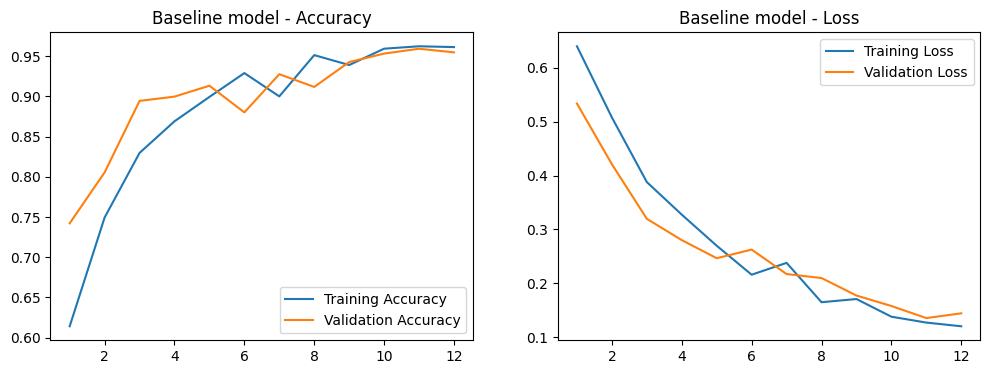

In [12]:
plot_accuracy_loss(history_baseline, title='Baseline model')

In [13]:
baseline_summary_df = summarize_history(history_baseline, 'Baseline')
baseline_val_results = evaluate_model(
    baseline_model,
    val_ds,
    class_names=class_names,
    model_name='Baseline',
    dataset_name='Validation',
    show_confusion_matrix=False,
    print_classification_report=False,
    verbose=False
)
display(baseline_summary_df)

,model,epochs_ran,best_train_accuracy,final_train_accuracy,best_val_accuracy,final_val_accuracy,best_val_loss,final_val_loss
0,Baseline,12,0.9623,0.9613,0.9593,0.9548,0.1353,0.1441


In [14]:
baseline_validation_table = build_validation_comparison_table(baseline_summary_df, baseline_val_results)
baseline_validation_table

,model,epochs_ran,best_train_accuracy,final_train_accuracy,best_val_accuracy,final_val_accuracy,best_val_loss,final_val_loss,val_precision_defect,val_recall_defect,val_f1_defect
0,Baseline,12,0.9623,0.9613,0.9593,0.9548,0.1353,0.1441,0.9985,0.9203,0.9578


### Discussão do baseline

O baseline cumpre bem o papel de ponto de partida: é uma arquitetura curta, treina de forma estável e já consegue captar padrões relevantes nas imagens sem recorrer a uma estrutura demasiado agressiva.  
Nos gráficos observa-se uma evolução consistente da **accuracy** e uma descida global da **loss**, o que confirma que mesmo uma CNN simples consegue aprender bem esta tarefa.

Em validação, os resultados são já fortes para uma primeira abordagem (**best validation accuracy = 0.9593**, **final validation accuracy = 0.9548**, **best validation loss = 0.1353**, **final validation loss = 0.1441**).  
Além disso, a métrica de interesse para a classe de defeito também é elevada (**validation precision for defect = 0.9985**, **validation recall for defect = 0.9203**, **validation F1-score for defect = 0.9578**).

A leitura destes valores é importante: o modelo é muito preciso quando sinaliza uma peça defeituosa, o que significa que gera muito poucos falsos positivos na classe **def_front**. No entanto, o recall é mais baixo do que a precision, o que indica que ainda falha uma parte dos defeitos reais.  
Em termos práticos, o baseline já é uma referência bastante competente, mas ainda deixa espaço para melhorar a sensibilidade à deteção de defeitos sem comprometer a estabilidade do treino.


## Overfit model

### Objetivo desta etapa
Nesta segunda fase o objetivo já não é apenas melhorar resultados, mas perceber o que acontece quando o modelo ganha **mais capacidade de aprendizagem** e passa a ter maior facilidade em ajustar-se ao conjunto de treino.

### O que se pretende mostrar
Aqui procura-se observar se uma arquitetura mais forte:
- aprende muito bem o treino;
- atinge bons valores iniciais em validação;
- mas começa a perder estabilidade e generalização à medida que o treino avança.

### Porque esta arquitetura
Para provocar esse comportamento, o modelo foi construído com:
- mais blocos convolucionais;
- mais filtros;
- maior capacidade nas camadas finais;
- menos controlo sobre a generalização durante o treino.

A intenção desta etapa é tornar visível o risco de sobreajuste, isto é, a situação em que o modelo se adapta demasiado aos dados de treino e deixa de sustentar esse ganho em validação e teste.


In [15]:
complex_model = Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

complex_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

complex_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,460,417 (9.39 MB)

 Trainable params: 2,460,417 (9.39 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
EPOCHS_COMPLEX = 20

history_complex = complex_model.fit(
    overfit_train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_COMPLEX,
    verbose=1
)


Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 414ms/step - accuracy: 0.5400 - loss: 0.6875 - val_accuracy: 0.5754 - val_loss: 0.6339
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 448ms/step - accuracy: 0.6585 - loss: 0.6090 - val_accuracy: 0.7617 - val_loss: 0.5078
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 465ms/step - accuracy: 0.8140 - loss: 0.4329 - val_accuracy: 0.8401 - val_loss: 0.3701
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 450ms/step - accuracy: 0.8620 - loss: 0.3398 - val_accuracy: 0.6373 - val_loss: 0.7843
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 425ms/step - accuracy: 0.8765 - loss: 0.2969 - val_accuracy: 0.8560 - val_loss: 0.2851
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 575ms/step - accuracy: 0.9085 - loss: 0.2255 - val_accuracy: 0.9299 - val_loss: 0.2138
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 439ms/step - accuracy: 0.9170 - loss: 0.2084 - val_accuracy: 0.9261 - val_loss: 0.2085
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 467ms/step - accuracy: 0.9415 - loss: 0.1533 - val_accu

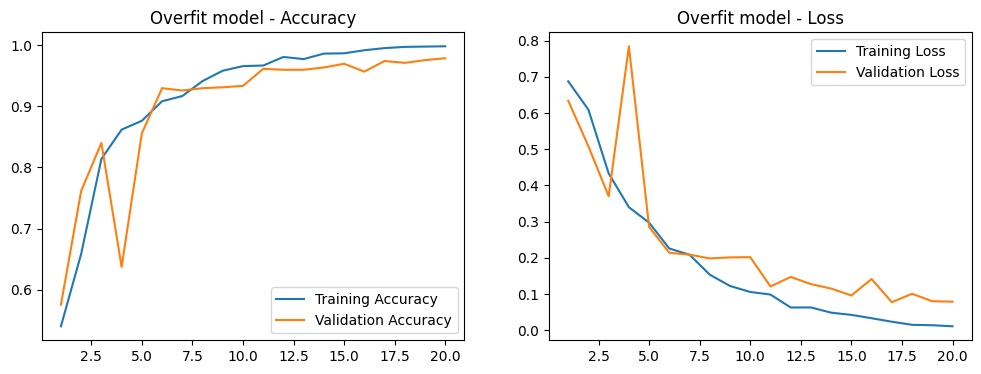

In [17]:
plot_accuracy_loss(history_complex, title='Overfit model')

In [18]:
complex_summary_df = summarize_history(history_complex, 'Overfit')
complex_val_results = evaluate_model(
    complex_model,
    val_ds,
    class_names=class_names,
    model_name='Overfit',
    dataset_name='Validation',
    show_confusion_matrix=False,
    print_classification_report=False,
    verbose=False
)
display(complex_summary_df)

,model,epochs_ran,best_train_accuracy,final_train_accuracy,best_val_accuracy,final_val_accuracy,best_val_loss,final_val_loss
0,Overfit,20,0.9985,0.9985,0.9789,0.9789,0.0774,0.0788


In [19]:
complex_validation_table = build_validation_comparison_table(complex_summary_df, complex_val_results)
complex_validation_table

,model,epochs_ran,best_train_accuracy,final_train_accuracy,best_val_accuracy,final_val_accuracy,best_val_loss,final_val_loss,val_precision_defect,val_recall_defect,val_f1_defect
0,Overfit,20,0.9985,0.9985,0.9789,0.9789,0.0774,0.0788,0.985,0.977,0.981


### Discussão do modelo com tendência a overfitting

O segundo modelo foi desenhado para **forçar uma maior tendência para overfitting**, aproximando-se da lógica pedida no trabalho.  
Para isso, foram introduzidas várias alterações em simultâneo:

- aumento da capacidade da rede (**mais camadas convolucionais e mais camadas densas**);
- utilização de um subconjunto de treino **mais pequeno** do que no baseline/regularized;
- treino durante **mais epochs**;
- ausência de mecanismos explícitos de controlo como **L2**, **dropout**, **early stopping** e **ReduceLROnPlateau**.

A ideia por trás desta experiência foi simples: dar ao modelo mais capacidade para memorizar padrões do treino e, ao mesmo tempo, reduzir um pouco a diversidade de exemplos usados para aprender.

Os resultados mostram que esse objetivo foi parcialmente alcançado. A **training accuracy** sobe para valores praticamente perfeitos (**best/final train accuracy = 0.9985**), enquanto a validação também continua muito elevada (**best/final validation accuracy = 0.9789**).  
Ou seja, o modelo aprende extremamente bem o treino, mas esse ganho já não se traduz numa melhoria proporcional em validação.

O sinal de overfitting neste notebook existe, mas é **moderado** e não extremo. Isso vê-se sobretudo em três aspetos:
- diferença clara entre o desempenho quase perfeito no treino e o desempenho em validação;
- **validation loss final (0.0788)** ligeiramente acima da melhor **validation loss (0.0774)**;
- melhoria menos estável do que a observada no modelo regularizado.

Também na métrica focada na classe de defeito o modelo apresenta resultados muito fortes (**validation precision for defect = 0.9850**, **validation recall for defect = 0.9770**, **validation F1-score for defect = 0.9810**).  
Por isso, esta experiência não deve ser interpretada como “modelo mau”; deve ser interpretada como um modelo que, ao ganhar muita capacidade, fica **mais exposto** ao risco de memorizar o treino.

Aqui surge uma conclusão importante para o trabalho: **foi difícil obter um overfitting muito dramático porque o problema parece ser relativamente aprendível para CNNs**. A tarefa é binária, os padrões visuais associados às classes parecem razoavelmente consistentes, e mesmo o subconjunto de treino continua a fornecer informação suficiente para generalizar bem.  
os conjuntos de treino, validação e teste são muito semelhantes entre si em termos de contexto visual e origem dos dados, o que também ajuda a manter desempenho elevado fora do treino.

Assim, o facto de o overfitting não ser extremo **não enfraquece** o trabalho. Pelo contrário: mostra que a experiência foi feita corretamente, que se tentou criar condições para sobreajuste, e que o comportamento observado foi o que os dados permitiram revelar.  
**Tentou-se aumentar a tendência para overfitting e ela apareceu, mas de forma controlada/moderada porque o problema e o dataset não favorecem uma degradação acentuada da generalização**.


## Regularized model

### Objetivo desta etapa
Depois de observar o comportamento do modelo mais agressivo, a terceira fase procura manter uma arquitetura forte, mas introduzir mecanismos que reduzam a tendência para memorizar o treino.

### O que se pretende mostrar
Nesta etapa pretende-se verificar se a regularização consegue:
- controlar o sobreajuste observado anteriormente;
- estabilizar o comportamento em validação;
- melhorar a capacidade de generalização no conjunto de teste.

### O que é utilizado
Para isso são usados três elementos complementares:
- **Dropout**, para reduzir dependência excessiva entre neurónios;
- **L2 regularization**, para penalizar pesos excessivamente grandes;
- **Early stopping** e **ReduceLROnPlateau**, para controlar melhor a dinâmica do treino.

A intenção não é tornar o modelo mais fraco, mas sim mais robusto.


In [ ]:

kernel_regularizer = regularizers.L2(0.0001)

regularized_model = Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1)),
    layers.Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=kernel_regularizer),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu', kernel_regularizer=kernel_regularizer),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu', kernel_regularizer=kernel_regularizer),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=kernel_regularizer),
    layers.Dropout(0.20),
    layers.Dense(64, activation='relu', kernel_regularizer=kernel_regularizer),
    layers.Dropout(0.20),
    layers.Dense(1, activation='sigmoid')
])

regularized_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

regularized_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,460,417 (9.39 MB)

 Trainable params: 2,460,417 (9.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

EPOCHS_REGULARIZED = 20

history_regularized = regularized_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_REGULARIZED,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 472ms/step - accuracy: 0.5280 - loss: 0.7260 - val_accuracy: 0.7179 - val_loss: 0.6952 - learning_rate: 0.0010
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 408ms/step - accuracy: 0.6870 - loss: 0.6197 - val_accuracy: 0.8092 - val_loss: 0.4666 - learning_rate: 0.0010
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 422ms/step - accuracy: 0.8330 - loss: 0.4154 - val_accuracy: 0.8115 - val_loss: 0.3742 - learning_rate: 0.0010
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 416ms/step - accuracy: 0.8937 - loss: 0.2785 - val_accuracy: 0.9261 - val_loss: 0.2206 - learning_rate: 0.0010
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 623ms/step - accuracy: 0.9220 - loss: 0.2203 - val_accuracy: 0.9299 - val_loss: 0.1956 - learning_rate: 0.0010
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 426ms/step - accuracy: 0.9450 - loss: 0.1621 - val_accuracy: 0.9532 - val_loss: 0.1579 - learning_rate: 0.0010
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 420ms/step - accuracy: 0.9587 - loss: 0.

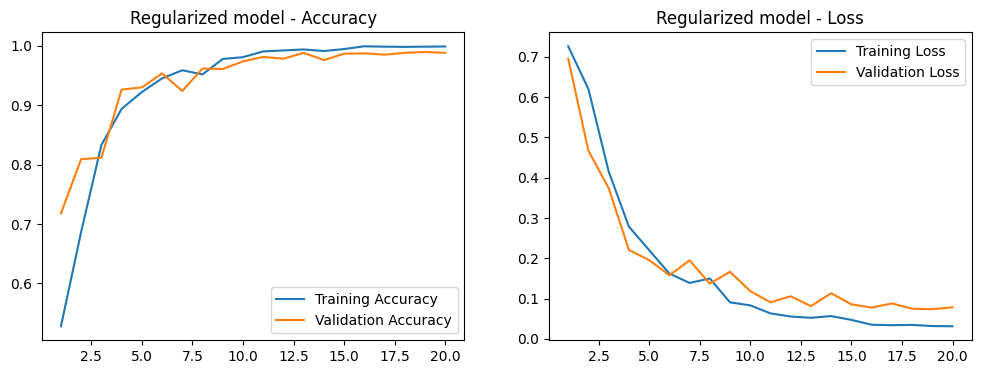

In [22]:
plot_accuracy_loss(history_regularized, title='Regularized model')

In [23]:
regularized_summary_df = summarize_history(history_regularized, 'Regularized')
regularized_val_results = evaluate_model(
    regularized_model,
    val_ds,
    class_names=class_names,
    model_name='Regularized',
    dataset_name='Validation',
    show_confusion_matrix=False,
    print_classification_report=False,
    verbose=False
)
display(regularized_summary_df)

,model,epochs_ran,best_train_accuracy,final_train_accuracy,best_val_accuracy,final_val_accuracy,best_val_loss,final_val_loss
0,Regularized,20,0.999,0.9987,0.9894,0.9879,0.0737,0.0783


In [24]:
regularized_validation_table = build_validation_comparison_table(regularized_summary_df, regularized_val_results)
regularized_validation_table

,model,epochs_ran,best_train_accuracy,final_train_accuracy,best_val_accuracy,final_val_accuracy,best_val_loss,final_val_loss,val_precision_defect,val_recall_defect,val_f1_defect
0,Regularized,20,0.999,0.9987,0.9894,0.9879,0.0737,0.0783,0.9986,0.9824,0.9905


### Discussão do modelo regularizado

O modelo regularizado é o que melhor fecha a lógica experimental do trabalho.  
A arquitetura continua forte, mas a introdução de **L2**, **dropout**, **early stopping** e **ReduceLROnPlateau** torna o treino mais controlado e reduz a probabilidade de memorizar o conjunto de treino em excesso.

Os resultados de validação mostram que esta combinação foi a mais eficaz: **best validation accuracy = 0.9894**, **final validation accuracy = 0.9879**, **best validation loss = 0.0737** e **final validation loss = 0.0783**.  
A diferença entre o melhor e o valor final é pequena, o que sugere um comportamento muito estável ao longo do treino. Além disso, as métricas para a classe de defeito são excelentes (**validation precision for defect = 0.9986**, **validation recall for defect = 0.9824**, **validation F1-score for defect = 0.9905**).

Comparando com os modelos anteriores, este modelo consegue manter desempenho muito alto e melhorar a generalização sem depender apenas do aumento bruto de capacidade.  
A interpretação mais importante é esta: o modelo intermédio mostrou que aumentar complexidade ajuda, mas também aumenta a exposição ao sobreajuste; já o modelo regularizado mostra que é possível manter essa capacidade representacional e, ao mesmo tempo, controlar melhor o treino.

O resultado final é uma solução mais equilibrada: muito precisa na identificação de defeitos, muito estável em validação e mais adequada para ser escolhida como modelo final.


In [25]:
comparison_df = pd.concat(
    [baseline_validation_table, complex_validation_table, regularized_validation_table],
    ignore_index=True
).sort_values(by=['best_val_accuracy', 'final_val_loss'], ascending=[False, True]).reset_index(drop=True)

In [26]:
comparison_df

,model,epochs_ran,best_train_accuracy,final_train_accuracy,best_val_accuracy,final_val_accuracy,best_val_loss,final_val_loss,val_precision_defect,val_recall_defect,val_f1_defect
0,Regularized,20,0.9990,0.9987,0.9894,0.9879,0.0737,0.0783,0.9986,0.9824,0.9905
1,Overfit,20,0.9985,0.9985,0.9789,0.9789,0.0774,0.0788,0.9850,0.9770,0.9810
2,Baseline,12,0.9623,0.9613,0.9593,0.9548,0.1353,0.1441,0.9985,0.9203,0.9578


## Seleção do modelo final

A escolha do modelo final é feita com base em critérios observados **sem recorrer ao conjunto de teste**.  
Para esta decisão, consideram-se sobretudo:
- comportamento ao longo do treino;
- estabilidade em validação;
- melhor compromisso entre **validation accuracy**, **validation loss** e **validation F1-score da classe defeituosa**.

Com esse critério, o **modelo regularizado** é a melhor escolha.  
O baseline funciona bem como referência inicial e apresenta resultados já fortes, mas continua menos sensível à deteção de defeitos do que os restantes modelos. O modelo intermédio atinge desempenho muito elevado, mas o seu papel principal neste workflow é experimental: mostrar o que acontece quando se aumenta a capacidade da rede e se criam condições mais favoráveis ao overfitting.

O modelo regularizado consegue combinar os dois aspetos mais importantes para esta tarefa:  
- desempenho muito elevado em validação;  
- comportamento mais estável e controlado ao longo do treino.

Por isso, esta é a solução mais consistente para avançar para a avaliação final no conjunto de teste. Em termos de apresentação, esta escolha também é fácil de defender: **não foi selecionado o modelo que apenas aprende mais o treino, mas sim o modelo que generaliza melhor de forma estável**.


In [27]:
best_model_name = 'Regularized'
best_model = regularized_model

final_candidates_df = comparison_df[comparison_df['model'].isin(['Baseline', 'Regularized'])].copy()
final_candidates_df.sort_values(by=['best_val_accuracy', 'final_val_loss'], ascending=[False, True]).reset_index(drop=True)

,model,epochs_ran,best_train_accuracy,final_train_accuracy,best_val_accuracy,final_val_accuracy,best_val_loss,final_val_loss,val_precision_defect,val_recall_defect,val_f1_defect
0,Regularized,20,0.9990,0.9987,0.9894,0.9879,0.0737,0.0783,0.9986,0.9824,0.9905
1,Baseline,12,0.9623,0.9613,0.9593,0.9548,0.1353,0.1441,0.9985,0.9203,0.9578


# Avaliação final do modelo selecionado

Depois de escolhido o melhor modelo com base na validação, esta secção apresenta a avaliação detalhada apenas dessa solução final no conjunto de teste.  
A ideia é concentrar aqui a análise mais completa, evitando usar o teste para orientar a escolha entre modelos.

Nesta fase faz sentido observar:
- métricas finais de classificação;
- **classification report**;
- **confusion matrix**;
- e, no fim, um exemplo prático de previsão sobre uma imagem individual do conjunto de teste.

Regularized - Test accuracy: 0.9930
Regularized - Test precision (def_front): 0.9978
Regularized - Test recall (def_front): 0.9912
Regularized - Test F1-score (def_front): 0.9945

              precision    recall  f1-score   support

   def_front       1.00      0.99      0.99       453
    ok_front       0.98      1.00      0.99       262

    accuracy                           0.99       715
   macro avg       0.99      0.99      0.99       715
weighted avg       0.99      0.99      0.99       715



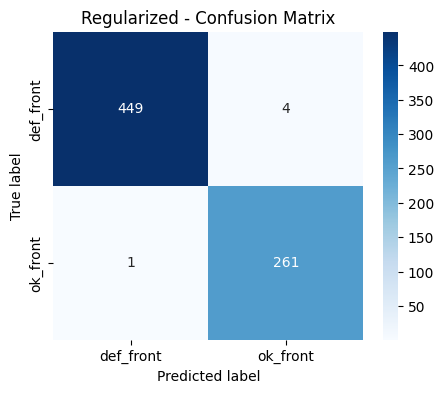

In [28]:
results = evaluate_model(
    best_model,
    test_ds,
    class_names=class_names,
    model_name=best_model_name,
    dataset_name='Test',
    show_confusion_matrix=True,
    print_classification_report=True,
    verbose=True
)

### Interpretação da avaliação final

A avaliação final em teste confirma que a escolha do modelo regularizado foi acertada.  
O modelo atinge **test accuracy = 0.9930**, **test precision (def_front) = 0.9978**, **test recall (def_front) = 0.9912** e **test F1-score = 0.9945**, valores muito elevados e consistentes com o que já se observava em validação.

A matriz de confusão mostra um número muito reduzido de erros, e o **classification report** confirma que o desempenho é forte nas duas classes. Em particular, o equilíbrio entre precisão e recall na classe de defeito indica que o modelo não só deteta corretamente a grande maioria dos defeitos, como o faz sem introduzir um número elevado de falsos alarmes.

Em termos práticos, esta etapa reforça a ideia de que a regularização não serviu apenas para controlar o treino, mas também para melhorar a capacidade de generalização do modelo em dados não vistos.  
Ou seja, a escolha final não foi apenas “o modelo com melhores números”: foi o modelo que apresentou a combinação mais consistente entre **qualidade preditiva**, **estabilidade** e **capacidade de generalização**.


## Exemplo prático com o modelo final

Para além das métricas globais, é útil observar uma previsão concreta do modelo selecionado.  
Nesta secção é mostrada uma imagem do conjunto de teste, a respetiva classe real e a previsão produzida pelo modelo final.



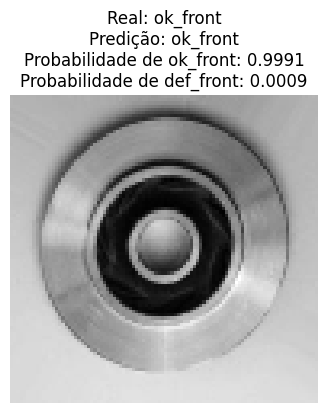

In [29]:
show_prediction_example(best_model, test_ds, class_names, n_examples=1, seed=42)

# Utilidade prática do modelo final

O modelo final pode ser enquadrado como uma ferramenta de apoio ao controlo de qualidade industrial, funcionando como um primeiro nível automático de triagem visual.  
Na prática, isto significa que imagens de peças recém-produzidas poderiam ser analisadas imediatamente após a fase de fabrico, sinalizando automaticamente aquelas que apresentam maior probabilidade de conter defeitos visíveis.

Uma solução com este tipo de desempenho tem utilidade prática em vários aspetos:
- **redução do tempo de inspeção**, ao automatizar uma tarefa repetitiva e visualmente exigente;
- **apoio à decisão humana**, servindo como filtro inicial antes da validação final por um operador;
- **maior consistência no processo**, reduzindo variações subjetivas entre inspeções manuais;
- **priorização de recursos**, permitindo concentrar a atenção dos operadores nas peças mais suspeitas;
- **potencial redução de custos**, ao diminuir o risco de peças defeituosas seguirem para fases posteriores do processo produtivo.

Além disso, a ênfase dada ao **recall da classe defeituosa** é particularmente relevante neste contexto. Em ambiente industrial, falhar a deteção de uma peça com defeito pode ter impacto operacional, económico e reputacional maior do que sinalizar uma peça boa para reinspeção.  
Por isso, um modelo com recall elevado para **def_front** é especialmente valioso como sistema de apoio real.

# Desenvolvimentos futuros

Apesar dos resultados obtidos serem muito fortes, existem várias extensões naturais que poderiam aumentar o valor prático do projeto.

Em primeiro lugar, faria sentido testar **data augmentation** de forma controlada, para aumentar a diversidade visual do treino e avaliar se o modelo mantém o desempenho quando confrontado com variações adicionais de iluminação, posição ou pequenas alterações de textura.  
Em segundo lugar, seria importante validar o modelo em **novos lotes de produção** ou em dados recolhidos em condições diferentes, para perceber se a generalização se mantém fora do conjunto atualmente utilizado.
Em terceiro lugar: estudar o impacto de diferentes limiares de decisão, ajustando o compromisso entre **precision** e **recall** para a classe defeituosa conforme a criticidade do processo industrial;



